In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from features.Carl import (
           total_number_of_sessions_1,
           time_last_used_1,
           feature_total_pages_count_1,
           exact_device_type_1,
           num_status_1,
           gender_feature_ont_hot_1,
           location_state_one_hot_encoded_1,
           member_since_1,
           num_different_songs_1,
           num_different_artists_1)



from pipeline import create_X_y_df, create_1_week_X_y_df, create_2_week_X_y_df

import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

In [2]:
np.random.seed(42)

In [3]:
full_dataset_df = pd.read_parquet("../../../data/churn-prediction-25-26/train.parquet")

In [4]:
full_dataset_df.sample(10)

# status -> Nelson
# gender -> Carl
# level -> Nelson
# ts -> Carl
# page -> Nelson
# location -> Carl
# itemInSession -> Nelson
# userAgent -> Carl
# method -> Nelson
# length -> Carl
# song -> Nelson
# artist -> Nelson
# time -> Carl
# registration -> Carl

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
8415245,200,M,August,paid,Clark,1207487,1540518498000,Logged In,NextSong,112798,"Riverside-San Bernardino-Ontario, CA",400,Mozilla/5.0 (Windows NT 6.1; Trident/7.0; rv:1...,PUT,236.04200,Hostile [Live Version],Pantera,2018-10-26 01:48:18,2018-09-10 17:03:47
12828473,200,F,Alani,paid,Kane,1325330,1541672419000,Logged In,NextSong,159518,"Tampa-St. Petersburg-Clearwater, FL",74,Mozilla/5.0 (Windows NT 6.1; rv:31.0) Gecko/20...,PUT,194.03710,Karibien,Air France,2018-11-08 10:20:19,2018-09-05 06:02:19
13490632,200,F,Angelina,paid,Singh,1495032,1541826321000,Logged In,NextSong,174513,"Santa Maria-Santa Barbara, CA",216,"""Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like...",PUT,278.07302,Through The Wire,Kanye West,2018-11-10 05:05:21,2018-08-24 13:24:27
9329450,200,M,Nathaniel,paid,Norris,1525270,1540794304000,Logged In,NextSong,128771,"San Francisco-Oakland-Hayward, CA",120,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,132.85832,Ride A White Swan,T. Rex,2018-10-29 06:25:04,2018-06-23 13:42:06
13901146,200,M,Landyn,paid,Evans,1849720,1541985370000,Logged In,NextSong,179047,"Atlanta-Sandy Springs-Roswell, GA",74,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,266.65751,Black Planet (Remastered),Sisters Of Mercy,2018-11-12 01:16:10,2018-08-25 21:44:42
930473,200,F,Alondra,paid,Johnson,1981365,1538601966000,Logged In,NextSong,35505,"Houston-The Woodlands-Sugar Land, TX",255,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.6; r...,PUT,579.83955,Kalopsia,Mark Otten,2018-10-03 21:26:06,2018-08-26 05:10:08
23244814,200,F,Georgia,paid,Walsh,1558947,1538958297000,Logged In,NextSong,7989,"Dallas-Fort Worth-Arlington, TX",12,"""Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/5...",PUT,201.79546,Revelry,Kings Of Leon,2018-10-08 00:24:57,2018-09-10 19:59:11
9200665,200,M,Jadon,paid,Benitez,1999781,1540750023000,Logged In,NextSong,132052,"San Diego-Carlsbad, CA",49,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.9; r...,PUT,98.14159,Samba De Una Nota SoÃÂ´,Joa~o Gilberto,2018-10-28 18:07:03,2018-08-31 02:26:28
5698983,200,F,Fatima,free,Hancock,1460110,1539845728000,Logged In,NextSong,74377,"New York-Newark-Jersey City, NY-NJ-PA",12,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,244.47955,Chana Masala,Looptroop,2018-10-18 06:55:28,2018-09-06 14:24:41
7062194,200,M,James,paid,Carlson,1588321,1540221175000,Logged In,NextSong,107607,"Cleveland-Elyria, OH",11,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:31....,PUT,218.27873,Tonight,FM Static,2018-10-22 15:12:55,2018-09-25 02:33:43


In [5]:
# Second Train Test set

#df_X, df_y = create_1_week_X_y_df(df = full_dataset_df)
df_X, df_y = create_2_week_X_y_df(df = full_dataset_df)

In [6]:
df_X["week_slice"].unique()

array([1, 2, 3])

In [7]:
def create_feature_engineered_df(df):
    feature_total_pages_count_df = feature_total_pages_count_1(df)
    total_number_of_sessions_df = total_number_of_sessions_1(df)
    time_last_used_df = time_last_used_1(df)


    #last_level_of_each_customer_df = last_level_of_each_customer_1(df)
    #usage_metrices_df = usage_metrices(df)
    num_status_df = num_status_1(df)
    device_type_df = exact_device_type_1(df)
    gender_feature_ont_hot_df = gender_feature_ont_hot_1(df)
    location_state_one_hot_encoded_df = location_state_one_hot_encoded_1(df)
    member_since_df = member_since_1(df)
    num_different_songs_df = num_different_songs_1(df)
    num_different_artists_df = num_different_artists_1(df)


    df = feature_total_pages_count_df.merge(total_number_of_sessions_df, on = ["userId", "week_slice"])

    df = df.merge(time_last_used_df, on = ["userId", "week_slice"])
    #df = df.merge(last_level_of_each_customer_df, on = ["userId", "week_slice"])
    #df = df.merge(usage_metrices_df, on = ["userId", "week_slice"])
    df = df.merge(num_status_df, on = ["userId", "week_slice"])
    df = df.merge(device_type_df, on = ["userId", "week_slice"])
    df = df.merge(gender_feature_ont_hot_df, on = ["userId", "week_slice"])
    df = df.merge(location_state_one_hot_encoded_df, on = ["userId", "week_slice"])
    df = df.merge(member_since_df, on = ["userId", "week_slice"])
    df = df.merge(num_different_songs_df, on = ["userId", "week_slice"])
    df = df.merge(num_different_artists_df, on = ["userId", "week_slice"])

    return feature_total_pages_count_df


df_X_features = create_feature_engineered_df(df_X)

/Users/aaron/Desktop/1_Studium/1_Master/1_Polytechnique/1_Courses/4_Python_for_Data_Science/2_Kaggle_Challenge/kaggle_challenge/src/features/Carl/device_used.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b.loc[:, "val"] = np.ones(len(df_b))


In [8]:
df_X_y = df_X_features.merge(df_y, on = ["userId", "week_slice"])

In [9]:
columns_X = df_X_features.columns.drop(["userId"])

columns_y = ["Cancellation Confirmation", "week_slice"]

In [10]:
df_X_y["week_slice"].unique()

array([1, 2, 3])

In [38]:
# Remove identifier column before scaling/modeling
X = df_X_y[columns_X]
y = df_X_y[columns_y]

#X_train, X_test, y_train, y_test = train_test_split(X, y)

X_train = X[X["week_slice"].isin([1, 3])]
X_test = X[X["week_slice"].isin([2])]

y_train = y[y["week_slice"].isin([1, 3])]
y_test = y[y["week_slice"].isin([2])]

In [39]:
X_train = X_train.drop(columns="week_slice")
X_test = X_test.drop(columns="week_slice")
y_train = y_train.drop(columns="week_slice")
y_test = y_test.drop(columns="week_slice")

In [40]:
y_train = y_train["Cancellation Confirmation"]
y_test = y_test["Cancellation Confirmation"]

In [41]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).\
    columns.tolist()


categorical_columns = X_train.select_dtypes(include=["object"]).\
    columns.tolist()

preprocesseor_lr=ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), num_cols),
        ("categorical", OneHotEncoder(), categorical_columns),
    ]
)

one_hot_dense_preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore",
                                 sparse_output=False),
                                 categorical_columns),
    ],
    remainder="passthrough"
)

model_lr = Pipeline([
    ("prepocesseor", preprocesseor_lr),
    ("model", LogisticRegression(max_iter=10000))#, class_weight={0:1, 1:10}))
])


model_hgbc = Pipeline([
    ("prepocesseor", one_hot_dense_preprocessor),
    ("model", HistGradientBoostingClassifier(max_depth=50))
])

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     12954
           1       1.00      0.00      0.00       750

    accuracy                           0.95     13704
   macro avg       0.97      0.50      0.49     13704
weighted avg       0.95      0.95      0.92     13704



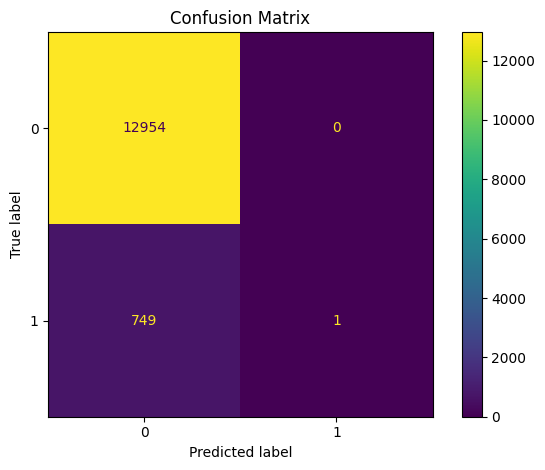

In [42]:
model_hgbc.fit(X_train, y_train)
pred = model_hgbc.predict(X_test)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
#cross_validate(model_hgbc, X, y, return_train_score=True)


#https://scikit-learn.org/stable/modules/ensemble.html#interpretation-with-feature-importance

[[12935    19]
 [  743     7]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     12954
           1       0.27      0.01      0.02       750

    accuracy                           0.94     13704
   macro avg       0.61      0.50      0.49     13704
weighted avg       0.91      0.94      0.92     13704



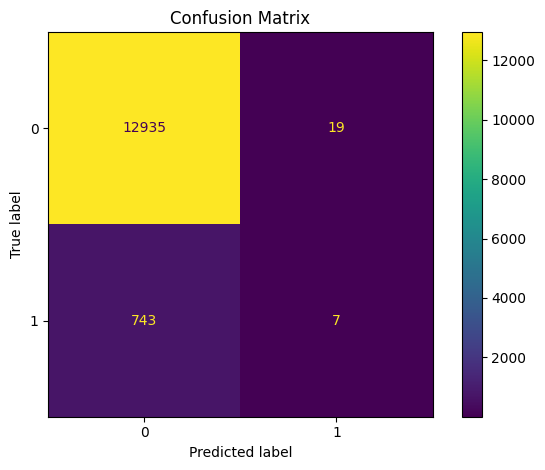

In [44]:


# 2) Preprocess: impute + one-hot for categoricals, impute for numerics
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # use sparse output by default
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, categorical_columns),
        ("num", numeric_pipeline, num_cols),
    ],
    remainder="passthrough"
)

# 3) Model
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"  # avoids warning in many setups
)


n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
spw = n_neg / max(n_pos, 1)

#xgb = XGBClassifier(scale_pos_weight = spw, eval_metric="aucpr")
xgb = XGBClassifier()

# 4) Full pipeline
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb)
])

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

# numeric matrix
cm = confusion_matrix(y_test, pred)
print(cm)

print(classification_report(y_test, pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [17]:
cross_validate(clf, X, y, return_train_score=True)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/xgboost/core.py", line 774, in inner_f
    return func(**

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

scores = cross_validate(
    clf, X, y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "f1", "roc_auc"],
    return_train_score=True
)
scores

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

oof_pred = cross_val_predict(clf, X, y, cv=cv, method="predict")

ConfusionMatrixDisplay.from_predictions(y, oof_pred, values_format="d")
plt.title("Out-of-fold Confusion Matrix (5-fold CV)")
plt.tight_layout()
plt.show()